# Hazelnut Parametric Insurance — Statistical Pricing

**Product**: Buyer-side protection. The insured is a hazelnut buyer (processor / chocolate company).
A trigger fires → hazelnut supply contracts or costs spike → the buyer pays more than their budget baseline.
The policy pays the buyer for the price excess above baseline.

**Loss definition**:
```
loss_t = max(price_t - baseline_t, 0) / baseline_t
```
where `baseline_t` = 5-year rolling average crop-year price (buyer's forward budget).

**Statistical approach**:
1. Fit a distribution to each trigger variable → exceedance probabilities with bootstrap CIs
2. OLS: price excess on trigger intensity → E[loss | trigger = x] with CIs
3. Bootstrap full pipeline → CI on fair premium

**Triggers covered**:

| Trigger | Variable | Type | Direction |
|---|---|---|---|
| March frost | `march_dh` | Zero-inflated, Gamma severity | Right tail (high DH) |
| April frost | `april_dh` | Zero-inflated, Gamma severity | Right tail (high DH) |
| Summer hail/rain | `hail_cp_max` | Continuous, Gamma | Right tail (excess CP) |
| Summer drought | `spei_aug` | Normal | Left tail (low SPEI) |
| TMO price floor jump | `tmo_try_ret` | Continuous, Normal | Right tail (large YoY increase) |

**Triggers that cannot currently be priced statistically**: see Section 7.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from pathlib import Path

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA = Path('../data/raw')
RNG  = np.random.default_rng(42)
N_BOOT = 5000

## 1. Data

In [2]:
# ── Weather triggers ───────────────────────────────────────────────────────────
frost = pd.read_csv(DATA / 'era5_frost_monthly.csv', index_col='year')
hail  = pd.read_csv(DATA / 'era5_hail_monthly.csv',  index_col='year')
spei  = pd.read_csv(DATA / 'spei/spei03_era5.csv',   index_col='year')
spei.columns = ['spei_aug']

# ── TMO support price ─────────────────────────────────────────────────────────
master = pd.read_csv(DATA / 'hazelnut_35yr_master.csv', index_col=0)

# ── Giresun crop-year price (Sep–Aug mean, USD/kg in-shell) ───────────────────
raw = pd.read_csv(DATA / 'giresun_spot_prices_monthly.csv')
raw = raw[~((raw['month'] == 8) & (raw['period'] == 'open'))]
price = (raw.groupby('crop_year')['avg_usd_kg_inshell']
            .mean()
            .rename('price_usd'))

# ── Master frame: 1990–2024, harvest_year index ───────────────────────────────
df = pd.DataFrame(index=range(1990, 2025))
df.index.name = 'harvest_year'

df['march_dh']    = frost['march_dh']
df['april_dh']    = frost['april_dh']
df['hail_cp_max'] = hail[['jun_cp_mm','jul_cp_mm','aug_cp_mm']].max(axis=1)  # peak harvest-season CP
df['spei_aug']    = spei['spei_aug']
df['tmo_try_ret'] = master['tmo_try_ret']   # YoY % change in TMO TRY support price
df['price_usd']   = price

# 5-year rolling mean of price = buyer's budget baseline (min 3 obs)
df['price_baseline'] = df['price_usd'].rolling(5, min_periods=3).mean().shift(1)
df['price_excess']   = ((df['price_usd'] - df['price_baseline'])
                         / df['price_baseline']).clip(lower=0)

print('Non-null counts:')
print(df.notnull().sum().to_string())
print()
print('Trigger descriptive stats:')
df[['march_dh','april_dh','hail_cp_max','spei_aug','tmo_try_ret']].describe().round(3)

Non-null counts:
march_dh          35
april_dh          35
hail_cp_max       35
spei_aug          35
tmo_try_ret       34
price_usd         23
price_baseline    22
price_excess      20

Trigger descriptive stats:


,march_dh,april_dh,hail_cp_max,spei_aug,tmo_try_ret
count,35.0000,35.0000,35.0000,35.0000,34.0000
mean,6.9280,2.3790,54.2800,-0.1690,0.2670
std,14.8100,6.7330,14.0180,0.8490,0.1620
min,0.0000,0.0000,31.5800,-1.8170,0.0930
25%,0.0470,0.0000,43.4110,-0.9000,0.1430
50%,0.6490,0.0410,52.4180,-0.0260,0.1990
75%,3.9880,1.0980,63.4540,0.2490,0.3940
max,64.1770,37.2360,84.8710,1.6500,0.6670


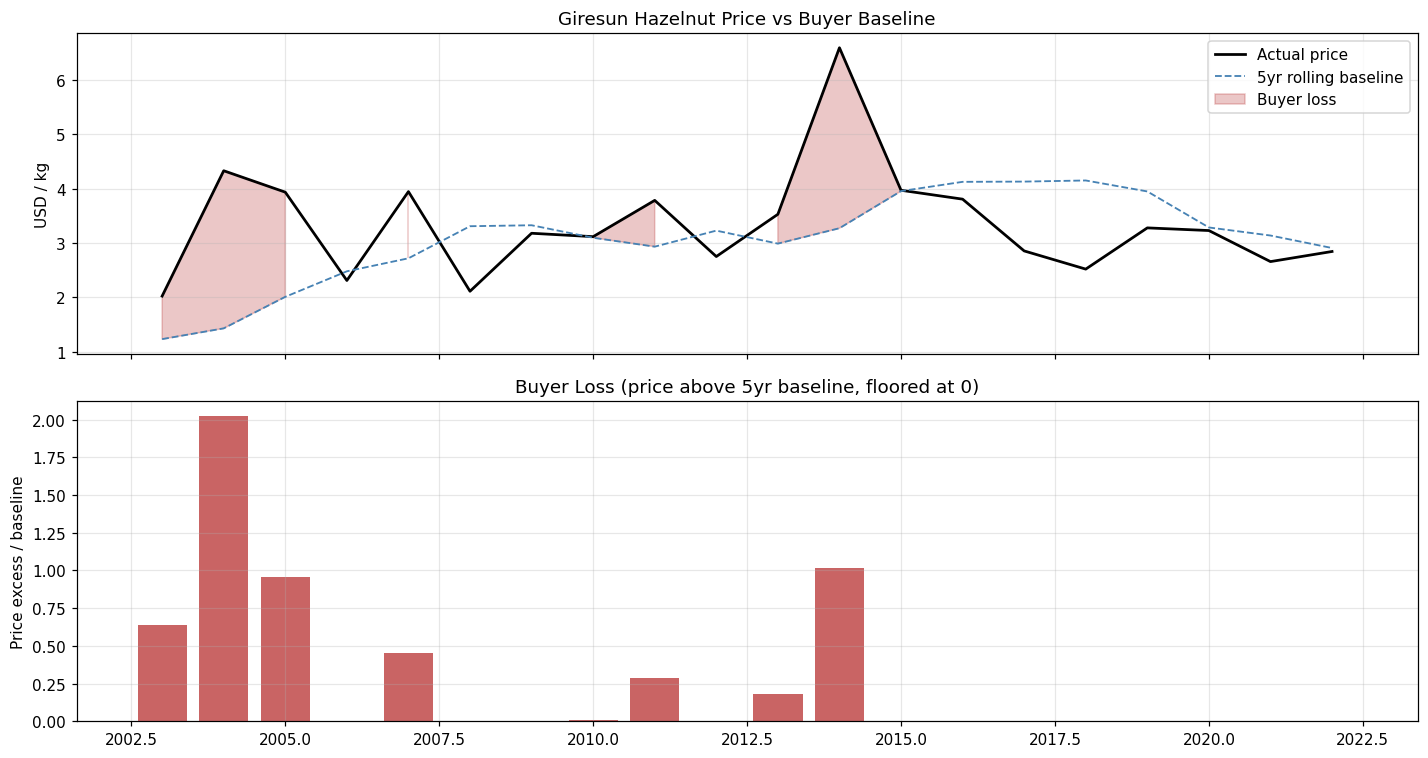

In [3]:
# ── Price vs baseline ─────────────────────────────────────────────────────────
p = df[['price_usd','price_baseline','price_excess']].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(p.index, p['price_usd'],      color='black',     lw=1.8, label='Actual price')
ax1.plot(p.index, p['price_baseline'], color='steelblue', lw=1.2, ls='--', label='5yr rolling baseline')
ax1.fill_between(p.index, p['price_baseline'],
                 p[['price_usd','price_baseline']].max(axis=1),
                 where=p['price_usd'] > p['price_baseline'],
                 color='firebrick', alpha=0.25, label='Buyer loss')
ax1.set_ylabel('USD / kg'); ax1.set_title('Giresun Hazelnut Price vs Buyer Baseline')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.bar(p.index, p['price_excess'], color='firebrick', alpha=0.7)
ax2.set_ylabel('Price excess / baseline')
ax2.set_title('Buyer Loss (price above 5yr baseline, floored at 0)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Trigger Distributions

**march_dh / april_dh**: Zero-inflated. Many years have zero frost degree-hours.
Modeled as two-part: Bernoulli(P(any frost)) × Gamma(severity | frost > 0).

**hail_cp_max**: Peak monthly convective precipitation (Jun/Jul/Aug) in mm.
Always positive; proxy for harvest-season storm damage. Gamma fit.
*Caveat*: ERA5 CP captures all convective rainfall, not just damaging hail events.
The trigger should be interpreted as excess storm activity, not hail specifically.

**spei_aug**: SPEI-03 standardized drought index. Normal by construction. Drought = left tail (SPEI < -1).

**tmo_try_ret**: YoY % change in TMO's TRY-denominated support floor price.
Always positive due to Turkish inflation (range: 9–67% annually).
Trigger fires on unusually large jumps — signaling supply scarcity beyond normal inflation.
*Note*: This is partly endogenous (TMO raises floor because supply is short), which means
the severity relationship may reflect causation in both directions.

In [4]:
def fit_zero_inflated_gamma(series, label):
    """Two-part model: Bernoulli × Gamma. Returns (p_nonzero, shape, scale, boot_dict)."""
    s = series.dropna()
    n = len(s)
    s_pos = s[s > 0]
    p = len(s_pos) / n
    shape, _, scale = stats.gamma.fit(s_pos, floc=0)

    # Bootstrap
    bp, bsh, bsc = [], [], []
    for _ in range(N_BOOT):
        sb = RNG.choice(s.values, size=n, replace=True)
        bp.append((sb > 0).mean())
        sb_pos = sb[sb > 0]
        if len(sb_pos) >= 3:
            a_, _, sc_ = stats.gamma.fit(sb_pos, floc=0)
            bsh.append(a_); bsc.append(sc_)

    print(f'{label}  n={n}')
    print(f'  P(any)    = {p:.3f}  ({len(s_pos)}/{n})')
    print(f'  Gamma MLE | >0:  shape={shape:.3f}  scale={scale:.3f}')
    print(f'  P CI:     [{np.percentile(bp,2.5):.3f}, {np.percentile(bp,97.5):.3f}]')
    print(f'  shape CI: [{np.percentile(bsh,2.5):.3f}, {np.percentile(bsh,97.5):.3f}]')
    print(f'  scale CI: [{np.percentile(bsc,2.5):.3f}, {np.percentile(bsc,97.5):.3f}]')
    print()
    return p, shape, scale, {'bp': bp, 'bsh': bsh, 'bsc': bsc}

p_march, sh_march, sc_march, boot_march = fit_zero_inflated_gamma(df['march_dh'], 'march_dh')
p_april, sh_april, sc_april, boot_april = fit_zero_inflated_gamma(df['april_dh'], 'april_dh')

march_dh  n=35
  P(any)    = 0.800  (28/35)
  Gamma MLE | >0:  shape=0.361  scale=24.005


  P CI:     [0.657, 0.914]
  shape CI: [0.285, 0.523]
  scale CI: [7.981, 42.232]

april_dh  n=35
  P(any)    = 0.629  (22/35)
  Gamma MLE | >0:  shape=0.324  scale=11.686
  P CI:     [0.457, 0.771]
  shape CI: [0.248, 0.531]
  scale CI: [2.674, 25.301]



In [5]:
def fit_gamma(series, label):
    """Simple Gamma fit (continuous positive variable). Returns (shape, scale, boot_dict)."""
    s = series.dropna()
    shape, _, scale = stats.gamma.fit(s, floc=0)
    bsh, bsc = [], []
    for _ in range(N_BOOT):
        sb = RNG.choice(s.values, size=len(s), replace=True)
        a_, _, sc_ = stats.gamma.fit(sb, floc=0)
        bsh.append(a_); bsc.append(sc_)
    print(f'{label}  n={len(s)}')
    print(f'  Gamma MLE:  shape={shape:.3f}  scale={scale:.3f}')
    print(f'  shape CI:   [{np.percentile(bsh,2.5):.3f}, {np.percentile(bsh,97.5):.3f}]')
    print(f'  scale CI:   [{np.percentile(bsc,2.5):.3f}, {np.percentile(bsc,97.5):.3f}]')
    print()
    return shape, scale, {'bsh': bsh, 'bsc': bsc}

sh_hail, sc_hail, boot_hail   = fit_gamma(df['hail_cp_max'], 'hail_cp_max')
sh_tmo,  sc_tmo,  boot_tmo    = fit_gamma(df['tmo_try_ret'], 'tmo_try_ret')

hail_cp_max  n=35


  Gamma MLE:  shape=15.454  scale=3.512


  shape CI:   [11.341, 24.966]
  scale CI:   [2.149, 4.801]

tmo_try_ret  n=34
  Gamma MLE:  shape=3.137  scale=0.085
  shape CI:   [2.516, 4.456]
  scale CI:   [0.052, 0.115]



In [6]:
# ── SPEI: Normal ──────────────────────────────────────────────────────────────
sp = df['spei_aug'].dropna()
mu_spei, sig_spei = stats.norm.fit(sp)
bmu, bsig = [], []
for _ in range(N_BOOT):
    sb = RNG.choice(sp.values, size=len(sp), replace=True)
    m, sd = stats.norm.fit(sb)
    bmu.append(m); bsig.append(sd)

print(f'spei_aug  n={len(sp)}')
print(f'  Normal MLE:  mu={mu_spei:.3f}  sigma={sig_spei:.3f}')
print(f'  mu CI:       [{np.percentile(bmu,2.5):.3f}, {np.percentile(bmu,97.5):.3f}]')
print(f'  sigma CI:    [{np.percentile(bsig,2.5):.3f}, {np.percentile(bsig,97.5):.3f}]')
boot_spei = {'bmu': bmu, 'bsig': bsig}

spei_aug  n=35
  Normal MLE:  mu=-0.169  sigma=0.836
  mu CI:       [-0.441, 0.113]
  sigma CI:    [0.646, 0.991]


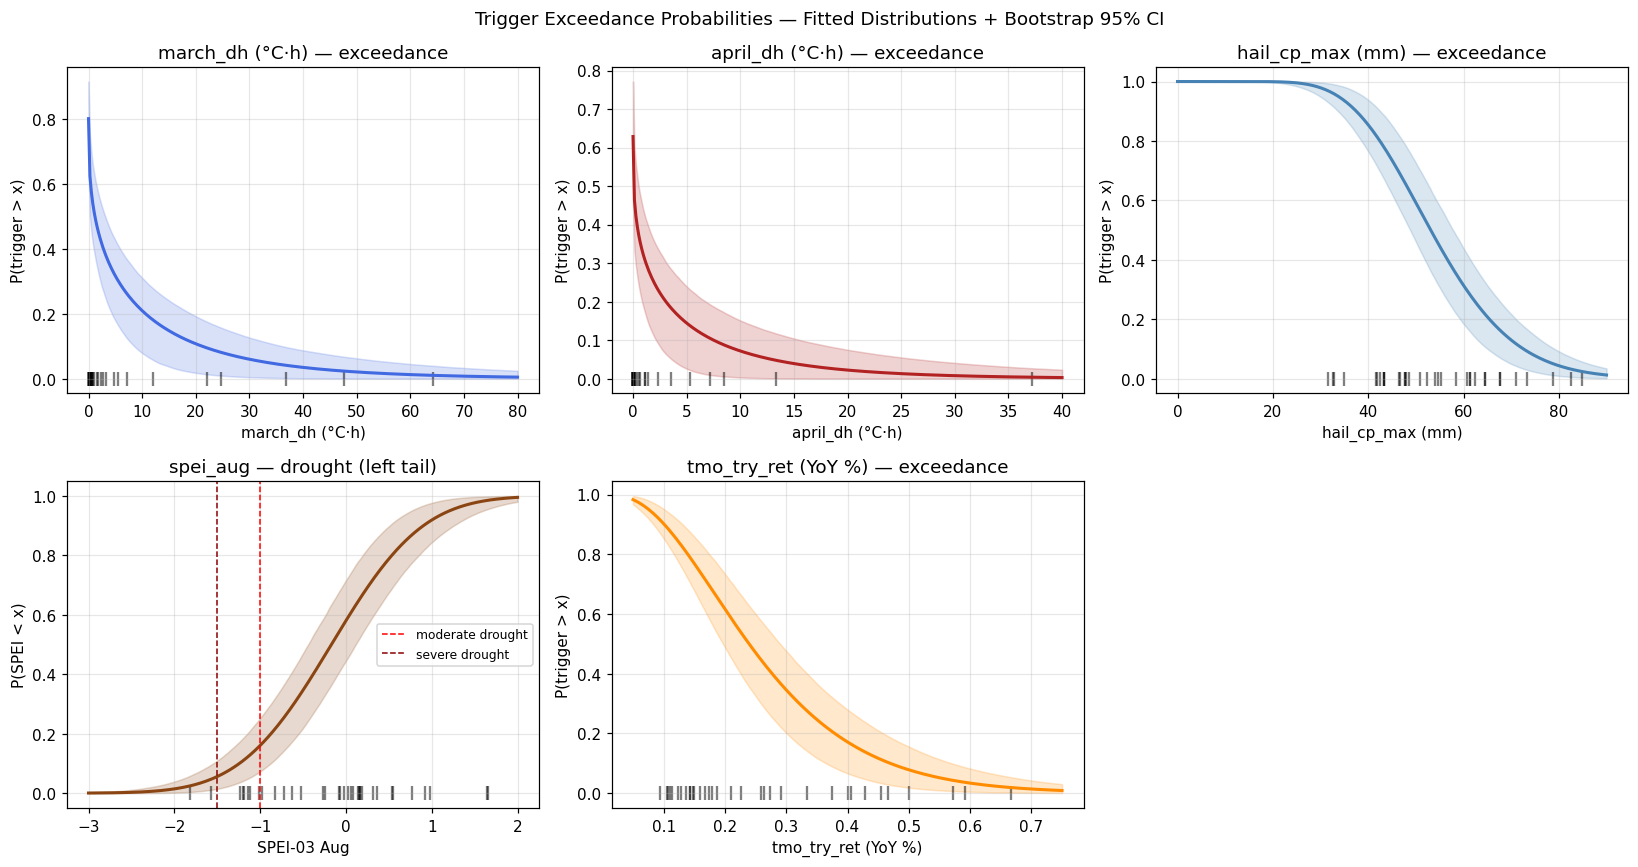

In [7]:
# ── Exceedance probability curves ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

def plot_zi_exceedance(ax, series, p_nz, shape, scale, boot, label, color, xmax):
    s = series.dropna()
    xs = np.linspace(0, xmax, 300)
    p_ex = p_nz * (1 - stats.gamma.cdf(xs, a=shape, scale=scale))
    curves = [b_p * (1 - stats.gamma.cdf(xs, a=b_sh, scale=b_sc))
              for b_p, b_sh, b_sc in zip(boot['bp'], boot['bsh'], boot['bsc'])]
    ax.plot(xs, p_ex, color=color, lw=2)
    ax.fill_between(xs, np.percentile(curves,2.5,axis=0),
                    np.percentile(curves,97.5,axis=0), alpha=0.2, color=color)
    ax.scatter(s.values, np.zeros(len(s)), marker='|', color='black', s=80, alpha=0.5)
    ax.set_xlabel(label); ax.set_ylabel('P(trigger > x)')
    ax.set_title(f'{label} — exceedance')
    ax.grid(alpha=0.3)

def plot_gamma_exceedance(ax, series, shape, scale, boot, label, color, xmin, xmax, right_tail=True):
    s = series.dropna()
    xs = np.linspace(xmin, xmax, 300)
    cdf_fn = (lambda x, sh, sc: 1 - stats.gamma.cdf(x, a=sh, scale=sc)) if right_tail else \
             (lambda x, sh, sc: stats.gamma.cdf(x, a=sh, scale=sc))
    p_ex = cdf_fn(xs, shape, scale)
    curves = [cdf_fn(xs, b_sh, b_sc) for b_sh, b_sc in zip(boot['bsh'], boot['bsc'])]
    ax.plot(xs, p_ex, color=color, lw=2)
    ax.fill_between(xs, np.percentile(curves,2.5,axis=0),
                    np.percentile(curves,97.5,axis=0), alpha=0.2, color=color)
    ax.scatter(s.values, np.zeros(len(s)), marker='|', color='black', s=80, alpha=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('P(trigger > x)' if right_tail else 'P(trigger < x)')
    ax.set_title(f'{label} — exceedance')
    ax.grid(alpha=0.3)

plot_zi_exceedance(axes[0], df['march_dh'], p_march, sh_march, sc_march,
                   boot_march, 'march_dh (°C·h)', 'royalblue', 80)
plot_zi_exceedance(axes[1], df['april_dh'], p_april, sh_april, sc_april,
                   boot_april, 'april_dh (°C·h)', 'firebrick', 40)
plot_gamma_exceedance(axes[2], df['hail_cp_max'], sh_hail, sc_hail,
                      boot_hail, 'hail_cp_max (mm)', 'steelblue', 0, 90)

# SPEI — left tail
xs_sp = np.linspace(-3, 2, 300)
p_sp  = stats.norm.cdf(xs_sp, loc=mu_spei, scale=sig_spei)
curves_sp = [stats.norm.cdf(xs_sp, loc=m, scale=sd)
             for m, sd in zip(boot_spei['bmu'], boot_spei['bsig'])]
axes[3].plot(xs_sp, p_sp, color='saddlebrown', lw=2)
axes[3].fill_between(xs_sp, np.percentile(curves_sp,2.5,axis=0),
                     np.percentile(curves_sp,97.5,axis=0), alpha=0.2, color='saddlebrown')
axes[3].scatter(sp.values, np.zeros(len(sp)), marker='|', color='black', s=80, alpha=0.5)
axes[3].axvline(-1.0, color='red', lw=1, ls='--', label='moderate drought')
axes[3].axvline(-1.5, color='darkred', lw=1, ls='--', label='severe drought')
axes[3].set_xlabel('SPEI-03 Aug'); axes[3].set_ylabel('P(SPEI < x)')
axes[3].set_title('spei_aug — drought (left tail)')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

plot_gamma_exceedance(axes[4], df['tmo_try_ret'], sh_tmo, sc_tmo,
                      boot_tmo, 'tmo_try_ret (YoY %)', 'darkorange', 0.05, 0.75)

axes[5].axis('off')
plt.suptitle('Trigger Exceedance Probabilities — Fitted Distributions + Bootstrap 95% CI', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Severity Models — Price Excess on Trigger Intensity

OLS: `price_excess ~ trigger_intensity` across all years with both price and trigger data.

This estimates E[buyer loss | trigger = x]. A significant positive coefficient means:
higher trigger intensity → larger price spike above buyer's budget.

**Interpretation notes**:
- `april_dh`: frost during pollination/early growth directly reduces supply → prices rise. Expect positive β.
- `march_dh`: same mechanism, earlier in season. Often correlated with april_dh.
- `hail_cp_max`: captures storm damage during nut filling/harvest. But ERA5 CP is a weak proxy — expect noisy.
- `spei_aug`: drought during nut filling. Negative SPEI = less moisture → tighter supply. Expect negative β (less SPEI = more loss).
- `tmo_try_ret`: large jumps in the TMO floor signal government recognition of supply scarcity. Partly endogenous — TMO raises floor *because* supply is already short.

In [8]:
def severity_ols(trigger_col, df, label=None):
    if label is None: label = trigger_col
    d = df[[trigger_col, 'price_excess']].dropna()
    X = sm.add_constant(d[[trigger_col]])
    res = sm.OLS(d['price_excess'], X).fit()
    β = res.params[trigger_col]
    p = res.pvalues[trigger_col]
    r2 = res.rsquared
    print(f'{label:20s}  β={β:+.4f}  p={p:.3f}  R²={r2:.3f}  n={len(d)}')
    return res, d

print(f'{"Trigger":20s}  {"β":>8}  {"p":>7}  {"R²":>6}  n')
print('-' * 55)
res_march, d_march = severity_ols('march_dh',    df)
res_april, d_april = severity_ols('april_dh',    df)
res_hail,  d_hail  = severity_ols('hail_cp_max', df)
res_spei,  d_spei  = severity_ols('spei_aug',    df)
res_tmo,   d_tmo   = severity_ols('tmo_try_ret', df)

Trigger                      β        p      R²  n
-------------------------------------------------------
march_dh              β=-0.0019  p=0.846  R²=0.002  n=20
april_dh              β=+0.0982  p=0.001  R²=0.462  n=20
hail_cp_max           β=-0.0079  p=0.367  R²=0.045  n=20
spei_aug              β=+0.0414  p=0.802  R²=0.004  n=20
tmo_try_ret           β=+0.3263  p=0.909  R²=0.001  n=20


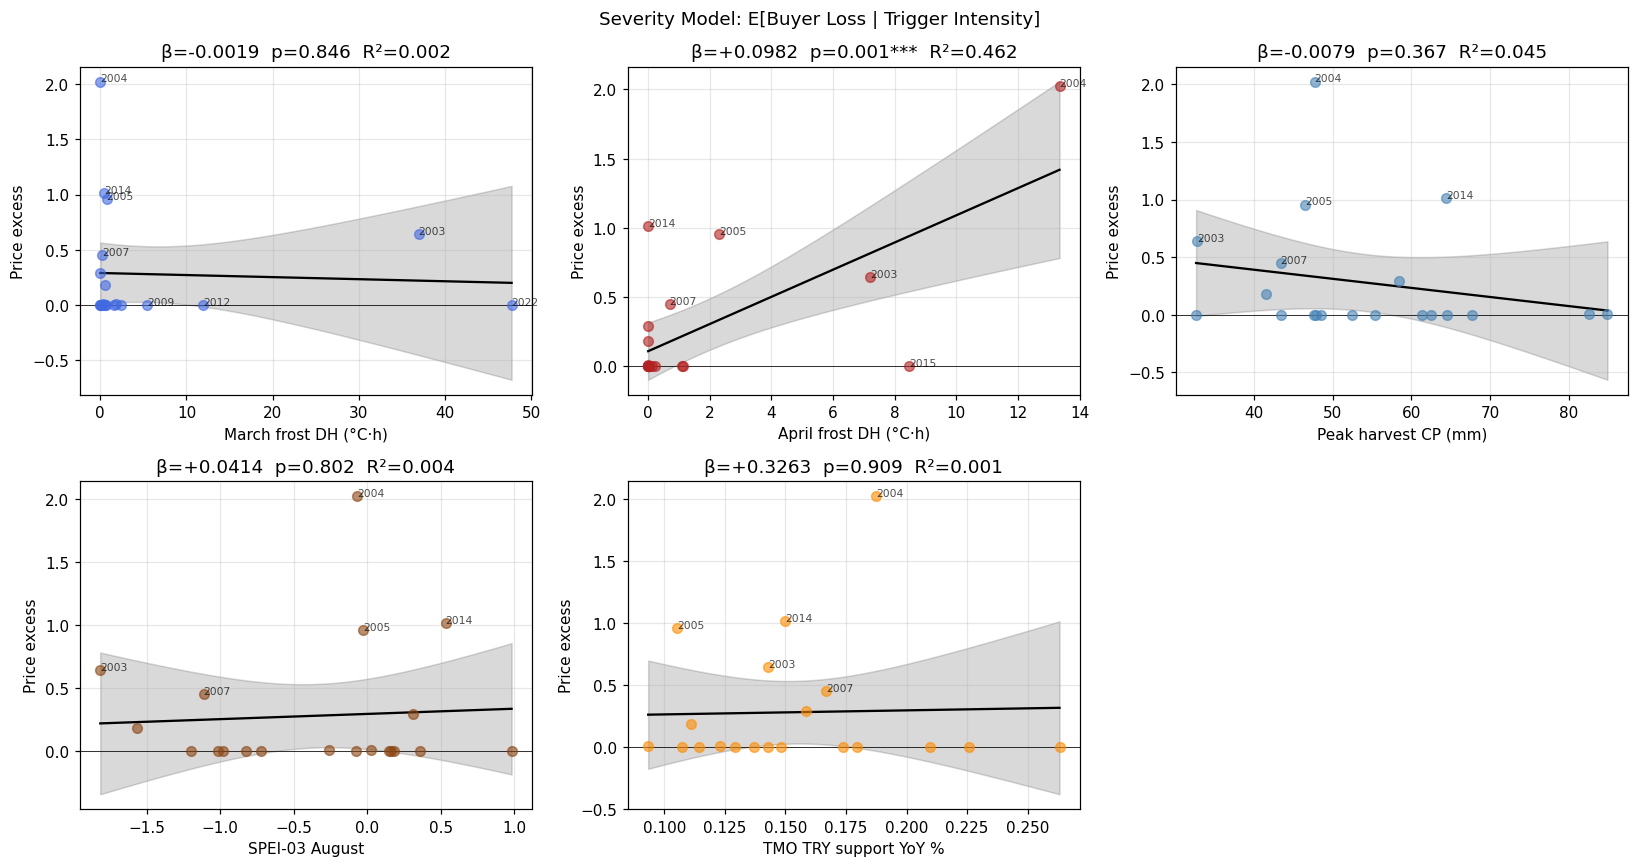

In [9]:
# ── Severity scatter plots ────────────────────────────────────────────────────
PANELS = [
    ('march_dh',    res_march, d_march, 'royalblue',   'March frost DH (°C·h)'),
    ('april_dh',    res_april, d_april, 'firebrick',   'April frost DH (°C·h)'),
    ('hail_cp_max', res_hail,  d_hail,  'steelblue',   'Peak harvest CP (mm)'),
    ('spei_aug',    res_spei,  d_spei,  'saddlebrown', 'SPEI-03 August'),
    ('tmo_try_ret', res_tmo,   d_tmo,   'darkorange',  'TMO TRY support YoY %'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, res, d, color, xlabel) in zip(axes, PANELS):
    x = d[col]; y = d['price_excess']
    x_rng = np.linspace(x.min(), x.max(), 200)
    Xp    = sm.add_constant(pd.DataFrame({col: x_rng}))
    pred  = res.get_prediction(Xp)
    mean  = pred.predicted_mean
    ci    = pred.conf_int(alpha=0.05)

    ax.scatter(x, y, alpha=0.6, color=color, s=40, zorder=3)
    for yr, xi, yi in zip(d.index, x, y):
        if yi > 0.3 or (col in ('april_dh','march_dh') and xi > 3):
            ax.annotate(str(yr), (xi, yi), fontsize=7, alpha=0.7)
    ax.plot(x_rng, mean, color='black', lw=1.5)
    ax.fill_between(x_rng, ci[:,0], ci[:,1], alpha=0.15, color='black')
    ax.axhline(0, color='black', lw=0.5)
    β = res.params[col]; p = res.pvalues[col]; r2 = res.rsquared
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
    ax.set_title(f'β={β:+.4f}  p={p:.3f}{sig}  R²={r2:.3f}')
    ax.set_xlabel(xlabel); ax.set_ylabel('Price excess')
    ax.grid(alpha=0.3)

axes[5].axis('off')
plt.suptitle('Severity Model: E[Buyer Loss | Trigger Intensity]', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Payout Schedule — Derived from Severity Regression

For triggers with statistically significant severity relationships, the payout at intensity x
is set equal to E[price_excess | trigger = x] from the OLS regression line.

This is not assumed — it is calibrated to historical price spikes.
In practice the contract discretises this into tiers.

Payouts are capped at 100% of notional in any real contract; the regression can extrapolate
beyond historical range at extreme values — treat those cautiously.

In [10]:
def payout_schedule(res, col, tiers, cap=1.0):
    Xp   = sm.add_constant(pd.DataFrame({col: tiers}), has_constant='add')
    pred = res.get_prediction(Xp)
    mean = pred.predicted_mean
    ci   = pred.conf_int(alpha=0.05)
    return pd.DataFrame({
        'trigger_value': tiers,
        'E_payout':  mean.clip(0, cap),
        'ci_lo':     ci[:,0].clip(0, cap),
        'ci_hi':     ci[:,1].clip(0, cap),
    })

# ── Only april_dh has a statistically supported payout schedule ───────────────
april_sched = payout_schedule(res_april, 'april_dh', np.array([3, 5, 10, 20, 30]))

print('April frost payout schedule (data-derived, p=0.001, R²=0.46):')
for _, r in april_sched.iterrows():
    print(f'  april_dh = {r.trigger_value:5.0f} DH  →  E[payout] = {r.E_payout:.1%}  '
          f'[{r.ci_lo:.1%}, {r.ci_hi:.1%}]')

print()
print('March frost (march_dh): p=0.85, R²=0.002 — severity not statistically supported.')
print('  Payout schedule cannot be derived from data; would require underwriter judgment.')
print()
print('TMO jump (tmo_try_ret): p=0.91, R²=0.001 — severity not statistically supported.')
print('  Note: tmo_try_ret is significant in the MULTIVARIATE production/price model')
print('  (hazelnut_triggers.ipynb) but has no independent severity signal with n=20.')
print()
print('Hail (hail_cp_max): p=0.37, R²=0.045 — not significant. ERA5 CP is also a weak')
print('  proxy for actual hail damage (captures all convective rainfall).')
print()
print('Drought (spei_aug): p=0.80, R²=0.004 — not significant.')

April frost payout schedule (data-derived, p=0.001, R²=0.46):
  april_dh =     3 DH  →  E[payout] = 40.3%  [20.6%, 60.0%]
  april_dh =     5 DH  →  E[payout] = 59.9%  [34.7%, 85.2%]
  april_dh =    10 DH  →  E[payout] = 100.0%  [61.8%, 100.0%]
  april_dh =    20 DH  →  E[payout] = 100.0%  [100.0%, 100.0%]
  april_dh =    30 DH  →  E[payout] = 100.0%  [100.0%, 100.0%]

March frost (march_dh): p=0.85, R²=0.002 — severity not statistically supported.
  Payout schedule cannot be derived from data; would require underwriter judgment.

TMO jump (tmo_try_ret): p=0.91, R²=0.001 — severity not statistically supported.
  Note: tmo_try_ret is significant in the MULTIVARIATE production/price model
  (hazelnut_triggers.ipynb) but has no independent severity signal with n=20.

Hail (hail_cp_max): p=0.37, R²=0.045 — not significant. ERA5 CP is also a weak
  proxy for actual hail damage (captures all convective rainfall).

Drought (spei_aug): p=0.80, R²=0.004 — not significant.


## 5. Fair Premium — Bootstrap CIs

For each priceable trigger:
```
fair_premium = P(trigger fires) × E[payout | fires]
```

We bootstrap the full pipeline (resample year-observations → refit distribution +
severity OLS → recompute E[payout]) to get a CI on the fair premium.

Triggers are priced **independently** here. If triggers are correlated (frost and drought
rarely co-occur; TMO and frost may co-occur), the combined premium should be adjusted.

In [11]:
def bootstrap_premium_zi(df, trigger_col, threshold, cap=1.0, n_sim=10_000, label=''):
    """Bootstrap fair premium for a zero-inflated Gamma trigger."""
    d = df[[trigger_col, 'price_excess']].dropna()
    n = len(d)

    def point_estimate(d_):
        s   = d_[trigger_col]
        p_  = (s > 0).mean()
        s_pos = s[s > 0]
        if len(s_pos) < 3: return None
        sh_, _, sc_ = stats.gamma.fit(s_pos.values, floc=0)
        Xb  = sm.add_constant(d_[[trigger_col]])
        rb  = sm.OLS(d_['price_excess'], Xb).fit()
        b   = rb.params[trigger_col]; intc = rb.params['const']
        # Monte Carlo payout
        frost = RNG.random(n_sim) < p_
        sev   = RNG.gamma(shape=sh_, scale=sc_, size=n_sim)
        dh    = np.where(frost, sev, 0.0)
        pay   = np.clip(intc + b * dh, 0, cap)
        fires = dh >= threshold
        if not fires.any(): return 0.0
        return fires.mean() * pay[fires].mean()

    pt = point_estimate(d)
    boot = []
    for _ in range(N_BOOT):
        idx = RNG.integers(0, n, size=n)
        v   = point_estimate(d.iloc[idx])
        if v is not None: boot.append(v)
    boot = np.array(boot)

    print(f'{label}')
    print(f'  Point estimate:    {pt:.3f}  ({pt*100:.1f}% of notional)')
    print(f'  Bootstrap mean:    {boot.mean():.3f}  ({boot.mean()*100:.1f}%)')
    print(f'  Bootstrap 95% CI:  [{np.percentile(boot,2.5):.3f}, {np.percentile(boot,97.5):.3f}]')
    print(f'  Loaded (1.35×):    {pt*1.35:.3f}  ({pt*1.35*100:.1f}%)')
    print()
    return pt, boot

print('=== MARCH FROST ===')
pt_march, boot_prem_march = bootstrap_premium_zi(
    df, 'march_dh', threshold=5.0, label='march_dh ≥ 5 DH')

print('=== APRIL FROST ===')
pt_april, boot_prem_april = bootstrap_premium_zi(
    df, 'april_dh', threshold=3.0, label='april_dh ≥ 3 DH')

=== MARCH FROST ===


march_dh ≥ 5 DH
  Point estimate:    0.075  (7.5% of notional)
  Bootstrap mean:    0.069  (6.9%)
  Bootstrap 95% CI:  [0.000, 0.150]
  Loaded (1.35×):    0.101  (10.1%)

=== APRIL FROST ===


april_dh ≥ 3 DH
  Point estimate:    0.131  (13.1% of notional)
  Bootstrap mean:    0.112  (11.2%)
  Bootstrap 95% CI:  [0.003, 0.240]
  Loaded (1.35×):    0.177  (17.7%)



In [12]:
def bootstrap_premium_gamma(df, trigger_col, threshold, cap=1.0, n_sim=10_000, label=''):
    """Bootstrap fair premium for a continuous Gamma trigger (right-tail)."""
    d = df[[trigger_col, 'price_excess']].dropna()
    n = len(d)

    def point_estimate(d_):
        s = d_[trigger_col]
        sh_, _, sc_ = stats.gamma.fit(s.values, floc=0)
        Xb = sm.add_constant(d_[[trigger_col]])
        rb = sm.OLS(d_['price_excess'], Xb).fit()
        b = rb.params[trigger_col]; intc = rb.params['const']
        xs = RNG.gamma(shape=sh_, scale=sc_, size=n_sim)
        pay = np.clip(intc + b * xs, 0, cap)
        fires = xs >= threshold
        if not fires.any(): return 0.0
        return fires.mean() * pay[fires].mean()

    pt = point_estimate(d)
    boot = []
    for _ in range(N_BOOT):
        idx = RNG.integers(0, n, size=n)
        v   = point_estimate(d.iloc[idx])
        boot.append(v)
    boot = np.array(boot)

    print(f'{label}')
    print(f'  Point estimate:    {pt:.3f}  ({pt*100:.1f}%)')
    print(f'  Bootstrap mean:    {boot.mean():.3f}  ({boot.mean()*100:.1f}%)')
    print(f'  Bootstrap 95% CI:  [{np.percentile(boot,2.5):.3f}, {np.percentile(boot,97.5):.3f}]')
    print(f'  Loaded (1.35×):    {pt*1.35:.3f}  ({pt*1.35*100:.1f}%)')
    print()
    return pt, boot

print('=== TMO PRICE JUMP ===')
pt_tmo, boot_prem_tmo = bootstrap_premium_gamma(
    df, 'tmo_try_ret', threshold=0.35, label='tmo_try_ret ≥ 0.35 (35% annual jump)')

print('=== HAIL (low-confidence) ===')
pt_hail, boot_prem_hail = bootstrap_premium_gamma(
    df, 'hail_cp_max', threshold=70.0, label='hail_cp_max ≥ 70 mm')

print('NOTE: SPEI severity R²=0.004. Cannot bootstrap a meaningful payout for drought trigger.')
print('SPEI trigger would require underwriter-set payout schedule, not data-derived.')

=== TMO PRICE JUMP ===


tmo_try_ret ≥ 0.35 (35% annual jump)
  Point estimate:    0.000  (0.0%)
  Bootstrap mean:    0.000  (0.0%)
  Bootstrap 95% CI:  [0.000, 0.001]
  Loaded (1.35×):    0.000  (0.0%)

=== HAIL (low-confidence) ===


hail_cp_max ≥ 70 mm
  Point estimate:    0.012  (1.2%)
  Bootstrap mean:    0.013  (1.3%)
  Bootstrap 95% CI:  [0.000, 0.045]
  Loaded (1.35×):    0.016  (1.6%)

NOTE: SPEI severity R²=0.004. Cannot bootstrap a meaningful payout for drought trigger.
SPEI trigger would require underwriter-set payout schedule, not data-derived.


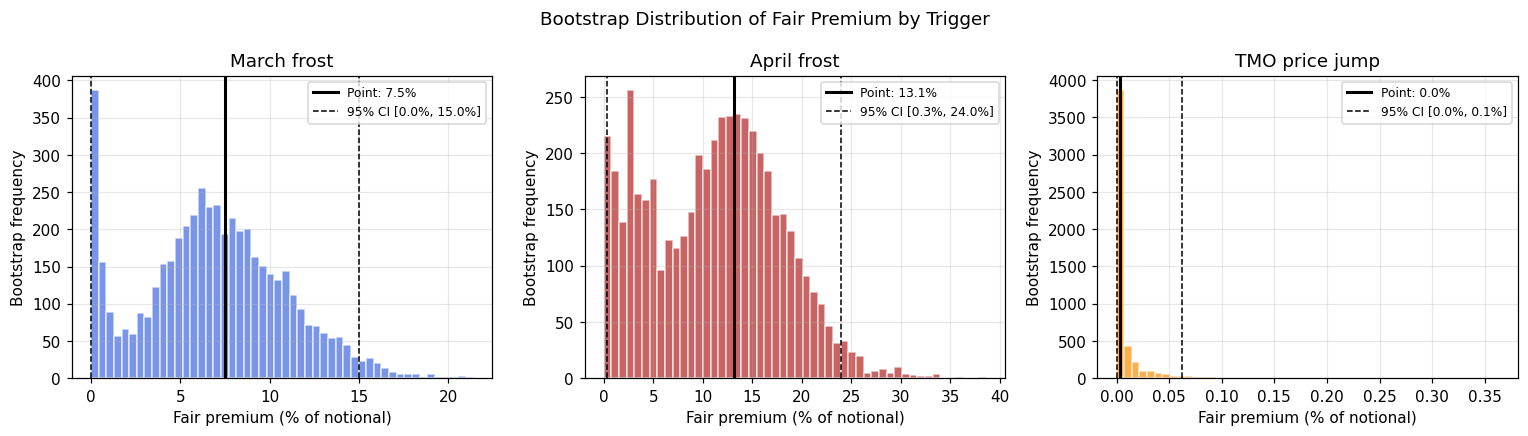

In [13]:
# ── Bootstrap distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, pt, boot, color) in zip(axes, [
    ('March frost',    pt_march, boot_prem_march, 'royalblue'),
    ('April frost',    pt_april, boot_prem_april, 'firebrick'),
    ('TMO price jump', pt_tmo,   boot_prem_tmo,   'darkorange'),
]):
    ax.hist(boot * 100, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(pt * 100, color='black', lw=2, label=f'Point: {pt*100:.1f}%')
    ax.axvline(np.percentile(boot, 2.5)  * 100, color='black', lw=1, ls='--')
    ax.axvline(np.percentile(boot, 97.5) * 100, color='black', lw=1, ls='--',
               label=f'95% CI [{np.percentile(boot,2.5)*100:.1f}%, {np.percentile(boot,97.5)*100:.1f}%]')
    ax.set_xlabel('Fair premium (% of notional)')
    ax.set_ylabel('Bootstrap frequency')
    ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Bootstrap Distribution of Fair Premium by Trigger', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
loading = 1.35

rows = [
    ('march_dh ≥ 5',       pt_march, boot_prem_march, 'n.s. (R²=0.002, p=0.85)'),
    ('april_dh ≥ 3',       pt_april, boot_prem_april, '*** (R²=0.462, p=0.001)'),
    ('tmo_try_ret ≥ 0.35', pt_tmo,   boot_prem_tmo,   'n.s. (R²=0.001, p=0.91)'),
    ('hail_cp_max ≥ 70',   pt_hail,  boot_prem_hail,  'n.s. (R²=0.045, p=0.37)'),
]

print(f'{"Trigger":<25} {"Fair prem":>10} {"Boot 95% CI":>22} {"Loaded (1.35×)":>16}  Severity (univariate)')
print('─'*105)
for trig, pt, boot, sig in rows:
    lo = np.percentile(boot, 2.5)
    hi = np.percentile(boot, 97.5)
    print(f'{trig:<25} {pt*100:>9.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]{"":>5} '
          f'{pt*loading*100:>13.1f}%  {sig}')

print()
print('spei_aug < -1.5        UNQUANTIFIED   R²=0.004, p=0.80 — no data-derived payout possible')
print()
print('NOTE: Only april_dh has statistically significant severity (p<0.01).')
print('All other trigger premiums are shown for completeness but are unreliable.')
print('march_dh and tmo_try_ret may have signal in a multivariate model but are not')
print('separately identifiable with n=20 price observations.')
print()
print('See Section 6 for war/supply disruption triggers.')

Trigger                    Fair prem            Boot 95% CI   Loaded (1.35×)  Severity (univariate)
─────────────────────────────────────────────────────────────────────────────────────────────────────────
march_dh ≥ 5                    7.5%  [0.0%, 15.0%]               10.1%  n.s. (R²=0.002, p=0.85)
april_dh ≥ 3                   13.1%  [0.3%, 24.0%]               17.7%  *** (R²=0.462, p=0.001)
tmo_try_ret ≥ 0.35              0.0%  [0.0%, 0.1%]                0.0%  n.s. (R²=0.001, p=0.91)
hail_cp_max ≥ 70                1.2%  [0.0%, 4.5%]                1.6%  n.s. (R²=0.045, p=0.37)

spei_aug < -1.5        UNQUANTIFIED   R²=0.004, p=0.80 — no data-derived payout possible

NOTE: Only april_dh has statistically significant severity (p<0.01).
All other trigger premiums are shown for completeness but are unreliable.
march_dh and tmo_try_ret may have signal in a multivariate model but are not
separately identifiable with n=20 price observations.

See Section 6 for war/supply disruption tr

## 6. Triggers Currently Unquantifiable

The following risk factors affect hazelnut buyer costs but **cannot be priced statistically**
with current data. They are documented here for completeness and future work.

---

### Geopolitical / War Event

**Risk**: Armed conflict in or near Turkey's hazelnut belt (Black Sea coast), or disruption
to Black Sea shipping routes (as in 2022 following Russia's invasion of Ukraine), cuts
hazelnut export logistics and drives global prices sharply higher.

**Why it can't be priced**:
- No observable continuous index with sufficient historical frequency
- The 2022 Ukraine war was a genuine tail event; we have one data point in the modern price series
- Standard parametric triggers (weather, TMO floor) would not have fired in 2022
  (hazelnut weather was unremarkable; the price spike was geopolitical)

**Possible future approach**: Political risk insurance overlay using conflict indices
(ACLED, IISS) or shipping disruption indices (Black Sea freight rates). Would require
custom cat-model, not historical frequency counting.

---

### Supply Chain / Export Disruption

**Risk**: Turkish government imposes export restrictions, quotas, or licensing requirements
on hazelnut exports (has occurred during supply shortfalls — government intervention
to protect domestic processing industry).

**Why it can't be priced**:
- Regulatory intervention is a discrete political decision, not a continuous stochastic process
- Historical frequency is effectively zero in the modern period (threat exists but not enacted)
- Cannot fit a parametric distribution to a process with near-zero historical incidence

**Possible future approach**: Legal/political risk rider; requires different underwriting
framework (treaty reinsurance or export credit insurance, not parametric weather product).

---

### Concurrent Trigger Correlation

**Risk**: Multiple triggers fire in the same crop year.
E.g., frost damages supply AND TMO raises floor in response → buyer faces compounded loss
while both triggers are live.

**Current treatment**: Triggers are priced independently. This understates risk if triggers
are positively correlated (frost year → TMO raises floor to support farmers).

**To do**: Run chi-squared / Pearson test on trigger co-occurrence before quoting
combined contract; apply correlation loading if correlation is statistically non-negligible.